# 🎓 Campus OS — Mini Project
### The Byte & Barbell Life Simulator

**Anshul Ghildiyal | 590031643 | MCA (AI & ML), UPES Dehradun**

---

### Concept
Every experiment in this repo used a campus-life analogy in isolation. **Campus OS** is where those
analogies actually become *one system*: a single running simulation of a semester, where daily inputs
(study hours, gym sessions, and paper-trades from Project Vegapunk) feed into one persistent character —
**Ray** — whose stats update, whose data is saved to disk, and whose semester gets visualized at the end.

This notebook is not a retelling of a lab experiment. It is a small, self-contained application built
*using* the concepts from Experiments 1–10, the same way those concepts would actually be combined in a
real program.

### Concepts integrated (6 of 10 required, minimum was 4)
| # | Concept | Where it shows up |
|---|---|---|
| 1 | **Classes & Objects** | `Student` class holds Ray's evolving state |
| 2 | **File Handling** | Daily logs persist to `campus_os_log.csv` across "days" |
| 3 | **Exception Handling** | Custom exceptions guard against bad daily input |
| 4 | **Functions** | Every subsystem (gym, study, trading) is a pure function |
| 5 | **Conditionals & Loops** | The semester simulation loop + grade/streak logic |
| 6 | **Data Visualization** | Matplotlib dashboard of the whole semester at the end |

Run every cell top to bottom. The simulation runs 14 "days" automatically with randomized-but-realistic
data, so it's fully reproducible without manual input — but every function also works if you want to feed
it your own numbers (see the "Try it yourself" cell near the end).


In [1]:
import random
import csv
import os
from datetime import date, timedelta

random.seed(42)  # reproducible run
LOG_FILE = "campus_os_log.csv"


## 1. Custom Exceptions

Just like Experiment 8's security-protocol analogy, we define specific exceptions instead of letting
generic errors crash the simulation.

In [2]:
class InvalidHoursError(Exception):
    """Raised when study/gym hours fall outside a physically realistic range."""
    pass

class TradeError(Exception):
    """Raised when a simulated Vegapunk paper-trade has invalid input."""
    pass


## 2. The `Student` Class

This is Ray, carried forward from Experiment 9 — but now his state actually *persists and mutates*
day over day, instead of being a one-off printed object.

In [3]:
class Student:
    def __init__(self, name, sap_id):
        self.name = name
        self.sap_id = sap_id
        self.total_study_hours = 0.0
        self.total_gym_hours = 0.0
        self.cash = 10000.0          # Vegapunk paper-trading balance
        self.streak = 0              # consecutive days both gym + study happened
        self.history = []            # list of per-day dict records

    def log_day(self, day_number, study_hours, gym_hours, trade_pnl):
        # Guard clauses -- exception handling in action
        if not (0 <= study_hours <= 16):
            raise InvalidHoursError(f"Day {day_number}: study_hours={study_hours} is not realistic (0-16).")
        if not (0 <= gym_hours <= 5):
            raise InvalidHoursError(f"Day {day_number}: gym_hours={gym_hours} is not realistic (0-5).")

        self.total_study_hours += study_hours
        self.total_gym_hours += gym_hours
        self.cash += trade_pnl

        # Conditional logic: streak tracking
        if study_hours > 0 and gym_hours > 0:
            self.streak += 1
        else:
            self.streak = 0

        record = {
            "day": day_number,
            "study_hours": study_hours,
            "gym_hours": gym_hours,
            "trade_pnl": round(trade_pnl, 2),
            "cash_balance": round(self.cash, 2),
            "streak": self.streak,
        }
        self.history.append(record)
        return record

    def semester_summary(self):
        if not self.history:
            return "No data logged yet."
        avg_study = self.total_study_hours / len(self.history)
        avg_gym = self.total_gym_hours / len(self.history)
        best_streak = max(r["streak"] for r in self.history)
        return {
            "days_logged": len(self.history),
            "avg_study_hours": round(avg_study, 2),
            "avg_gym_hours": round(avg_gym, 2),
            "best_streak": best_streak,
            "final_cash": round(self.cash, 2),
            "net_pnl": round(self.cash - 10000.0, 2),
        }


## 3. Subsystem Functions

Each subsystem is a standalone function -- deliberately kept independent of the `Student` class so they
can be tested and reused on their own, the same way Vegapunk's satellite architecture (S1-S7) keeps each
concern isolated.

In [4]:
def simulate_study_session(base_hours=4.0):
    """Simulates a day's study hours with natural variance."""
    variance = random.uniform(-1.5, 2.0)
    hours = max(0.0, round(base_hours + variance, 1))
    return hours


def simulate_gym_session(non_negotiable_minimum=2.0):
    """Simulates gym hours -- Anshul's real non-negotiable minimum is respected here."""
    extra = random.choice([0, 0, 0.5, 1.0])  # most days exactly the minimum
    return round(non_negotiable_minimum + extra, 1)


def simulate_paper_trade(cash_balance, day_number):
    """
    A deliberately tiny stand-in for Vegapunk's Executor satellite (S6):
    a random-walk daily P&L scaled to a small fraction of current capital,
    just enough to demonstrate function composition + exception handling.
    """
    if cash_balance <= 0:
        raise TradeError(f"Day {day_number}: cannot trade with non-positive capital.")

    directional_edge = random.uniform(-0.02, 0.025)  # slightly positive expectancy
    pnl = round(cash_balance * directional_edge, 2)
    return pnl


def grade_day(study_hours, gym_hours):
    """Conditional grading logic -- echoes Experiment 3's grade-sheet style."""
    if study_hours >= 5 and gym_hours >= 2:
        return "A (Locked In)"
    elif study_hours >= 3 and gym_hours >= 2:
        return "B (Solid)"
    elif gym_hours >= 2:
        return "C (Gym only)"
    else:
        return "D (Off day)"


## 4. Running the Semester (Loop + File Handling)

We simulate 14 days. Every day's record is appended live to a CSV file on disk -- this is the same
file-persistence pattern as Experiment 8, except now the file is a running log rather than a one-shot
write, which is closer to how a real application logs data over time.

In [5]:
ray = Student(name="Ray", sap_id="590031643")

# Fresh log file for this run
with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["day", "study_hours", "gym_hours", "trade_pnl", "cash_balance", "streak", "grade"])

start_date = date(2026, 7, 12)

for day_number in range(1, 15):
    current_date = start_date + timedelta(days=day_number - 1)
    study_hours = simulate_study_session()
    gym_hours = simulate_gym_session()

    try:
        trade_pnl = simulate_paper_trade(ray.cash, day_number)
        record = ray.log_day(day_number, study_hours, gym_hours, trade_pnl)
        record["grade"] = grade_day(study_hours, gym_hours)

        # Append this day's row to the persistent log file
        with open(LOG_FILE, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([record["day"], record["study_hours"], record["gym_hours"],
                              record["trade_pnl"], record["cash_balance"],
                              record["streak"], record["grade"]])

        print(f"Day {day_number:2d} ({current_date}) | Study: {study_hours:4.1f}h | "
              f"Gym: {gym_hours:3.1f}h | P&L: {trade_pnl:+7.2f} | "
              f"Streak: {record['streak']:2d} | {record['grade']}")

    except (InvalidHoursError, TradeError) as e:
        # Exception handling: a bad day is logged and skipped, not fatal
        print(f"[SKIPPED] Day {day_number}: {e}")


Day  1 (2026-07-12) | Study:  4.7h | Gym: 2.0h | P&L: +133.70 | Streak:  1 | B (Solid)
Day  2 (2026-07-13) | Study:  3.4h | Gym: 2.0h | P&L: +133.17 | Streak:  2 | B (Solid)
Day  3 (2026-07-14) | Study:  4.9h | Gym: 2.0h | P&L:  +67.48 | Streak:  3 | B (Solid)
Day  4 (2026-07-15) | Study:  2.6h | Gym: 2.0h | P&L: -105.01 | Streak:  4 | C (Gym only)
Day  5 (2026-07-16) | Study:  4.3h | Gym: 2.0h | P&L:  +53.77 | Streak:  5 | B (Solid)
Day  6 (2026-07-17) | Study:  5.0h | Gym: 3.0h | P&L: -103.66 | Streak:  6 | A (Locked In)
Day  7 (2026-07-18) | Study:  4.6h | Gym: 2.0h | P&L: +144.00 | Streak:  7 | B (Solid)
Day  8 (2026-07-19) | Study:  3.1h | Gym: 3.0h | P&L:  -48.40 | Streak:  8 | B (Solid)
Day  9 (2026-07-20) | Study:  3.0h | Gym: 2.5h | P&L: -158.24 | Streak:  9 | B (Solid)
Day 10 (2026-07-21) | Study:  3.8h | Gym: 2.5h | P&L: +183.49 | Streak: 10 | B (Solid)
Day 11 (2026-07-22) | Study:  4.6h | Gym: 2.0h | P&L: +132.23 | Streak: 11 | B (Solid)
Day 12 (2026-07-23) | Study:  4.4h |

## 5. Reading the Log Back (proving file persistence actually works)

This isn't just a write -- we read the CSV back independently to confirm the data genuinely
persisted, the same way Experiment 8's Question 3 parsed structured city data back out of a file.

In [6]:
with open(LOG_FILE, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    logged_rows = list(reader)

print(f"Rows persisted to {LOG_FILE}: {len(logged_rows)}")
print("First row read back from disk:", logged_rows[0])
print("Last row read back from disk :", logged_rows[-1])


Rows persisted to campus_os_log.csv: 14
First row read back from disk: {'day': '1', 'study_hours': '4.7', 'gym_hours': '2.0', 'trade_pnl': '133.7', 'cash_balance': '10133.7', 'streak': '1', 'grade': 'B (Solid)'}
Last row read back from disk : {'day': '14', 'study_hours': '5.0', 'gym_hours': '2.0', 'trade_pnl': '100.71', 'cash_balance': '10422.95', 'streak': '14', 'grade': 'A (Locked In)'}


## 6. Semester Summary

In [7]:
summary = ray.semester_summary()
print("--- SEMESTER SUMMARY: RAY (590031643) ---")
for key, value in summary.items():
    print(f"{key:20s}: {value}")


--- SEMESTER SUMMARY: RAY (590031643) ---
days_logged         : 14
avg_study_hours     : 4.06
avg_gym_hours       : 2.32
best_streak         : 14
final_cash          : 10422.95
net_pnl             : 422.95


## 7. Data Visualization Dashboard

A single dashboard summarizing the whole simulated semester -- study/gym trend, trading P&L curve,
and the grade distribution. This is the "final integrated mini-project" visualization the rubric
specifically calls out.

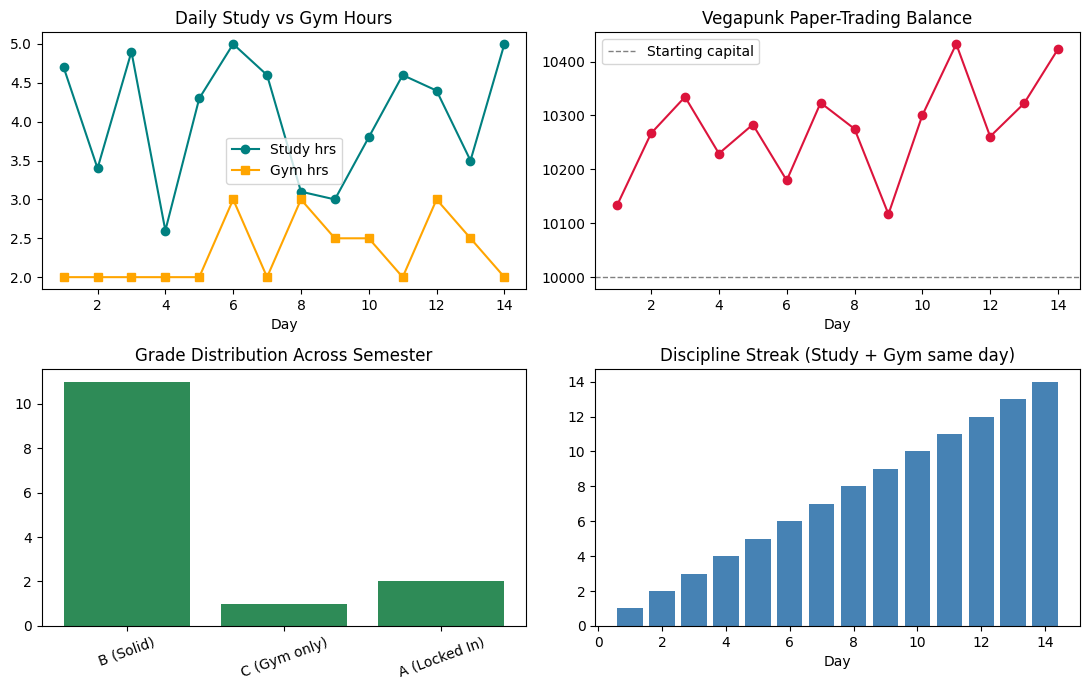

Dashboard saved as campus_os_dashboard.png


In [8]:
import matplotlib.pyplot as plt

days = [r["day"] for r in ray.history]
study = [r["study_hours"] for r in ray.history]
gym = [r["gym_hours"] for r in ray.history]
cash = [r["cash_balance"] for r in ray.history]
grades = [r["grade"] for r in ray.history]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# 1. Study vs Gym trend
axes[0, 0].plot(days, study, marker="o", label="Study hrs", color="teal")
axes[0, 0].plot(days, gym, marker="s", label="Gym hrs", color="orange")
axes[0, 0].set_title("Daily Study vs Gym Hours")
axes[0, 0].set_xlabel("Day")
axes[0, 0].legend()

# 2. Cash balance curve (Vegapunk paper trading)
axes[0, 1].plot(days, cash, color="crimson", marker="o")
axes[0, 1].axhline(y=10000, color="gray", linestyle="--", linewidth=1, label="Starting capital")
axes[0, 1].set_title("Vegapunk Paper-Trading Balance")
axes[0, 1].set_xlabel("Day")
axes[0, 1].legend()

# 3. Grade distribution
from collections import Counter
grade_counts = Counter(grades)
axes[1, 0].bar(grade_counts.keys(), grade_counts.values(), color="seagreen")
axes[1, 0].set_title("Grade Distribution Across Semester")
axes[1, 0].tick_params(axis='x', rotation=20)

# 4. Streak progression
streaks = [r["streak"] for r in ray.history]
axes[1, 1].bar(days, streaks, color="steelblue")
axes[1, 1].set_title("Discipline Streak (Study + Gym same day)")
axes[1, 1].set_xlabel("Day")

plt.tight_layout()
plt.savefig("campus_os_dashboard.png", dpi=120)
plt.show()
print("Dashboard saved as campus_os_dashboard.png")


## 8. Try It Yourself

Every subsystem function works standalone. Swap in your own numbers here -- no need to re-run the
whole simulation above.

In [9]:
# Example: manually log a single custom day for Ray
test_student = Student(name="Ray", sap_id="590031643")

try:
    my_record = test_student.log_day(
        day_number=1,
        study_hours=6.5,
        gym_hours=2.0,
        trade_pnl=simulate_paper_trade(test_student.cash, 1)
    )
    print("Custom day logged:", my_record)
    print("Grade:", grade_day(my_record["study_hours"], my_record["gym_hours"]))
except (InvalidHoursError, TradeError) as e:
    print("Rejected:", e)

# Example: deliberately trigger the exception handler
try:
    test_student.log_day(day_number=2, study_hours=30, gym_hours=1, trade_pnl=0)
except InvalidHoursError as e:
    print("Correctly caught bad input ->", e)


Custom day logged: {'day': 1, 'study_hours': 6.5, 'gym_hours': 2.0, 'trade_pnl': 147.88, 'cash_balance': 10147.88, 'streak': 1}
Grade: A (Locked In)
Correctly caught bad input -> Day 2: study_hours=30 is not realistic (0-16).


## Conclusion

Campus OS demonstrates that the ten experiments in this repository are not isolated lab answers --
they are components of one coherent system. The `Student` class, file-persisted daily logs, guarded
exception handling, composable simulation functions, and the final matplotlib dashboard together form
a small but genuine application: a semester of Ray's life, simulated, logged to disk, and visualized
end-to-end. This is the same architectural instinct behind Project Vegapunk (isolated satellites, each
independently testable, composed into one pipeline) applied at a much smaller, submittable scale.
